### Simulated Fe intensity outliers

In [1]:
from pathlib import Path
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from tqdm import tqdm

sys.path.append("..")
import roi_tools

rng = np.random.default_rng(0)
n_fp = 50
n_pristine_images = 30
n_down_images = 10
n_up_images = 20
down_target = (3, 3)
up_target = (4, 3)
layers = np.arange(25)

metric = "mean_intensity"

configs = {
    "4 Atoms": [(0, -2), (0, 2), (-1, 0), (1, 0)],
    "8 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
    ],
    "14 Atoms": [
        (0, -2), (0, 2),
        (-1, -2), (-1, 0), (-1, 2),
        (1, -2), (1, 0), (1, 2),
        (-2, -2), (-2, 0), (-2, 2),
        (2, -2), (2, 0), (2, 2),
    ],
}


def indexed_files(folder, pattern):
    return sorted(
        folder.glob(pattern),
        key=lambda path: int(path.stem.rsplit("_", 1)[1]),
    )


def mean_selected(files, indices):
    return np.mean(
        np.stack([np.load(files[index]).squeeze() for index in indices]),
        axis=0,
    )


pristine_dir = Path("../data/simulations/pristine_fp")
pristine_files = indexed_files(pristine_dir, "pristine_fp_*.npy")


def defect_files(defect):
    defect_dir = Path("../data/simulations") / defect
    return {
        layer: indexed_files(
            defect_dir / f"{defect}_layer_{layer}",
            f"{defect}_layer_{layer}_ensemble_*.npy",
        )
        for layer in layers
    }


down_files = defect_files("LuFe_down")
up_files = defect_files("LuFe_up")

def random_index_sets(n_available, n_images):
    return np.array([
        np.sort(rng.choice(n_available, n_fp, replace=False))
        for _ in range(n_images)
    ])


pristine_index_sets = random_index_sets(len(pristine_files), n_pristine_images)
down_index_sets = random_index_sets(len(down_files[layers[0]]), n_down_images)
up_index_sets = random_index_sets(len(up_files[layers[0]]), n_up_images)
pristine_images = [
    mean_selected(pristine_files, indices)
    for indices in tqdm(pristine_index_sets, desc="Building pristine ensembles")
]


def build_defect_images(files_by_layer, index_sets, description):
    return {
        layer: [mean_selected(files, indices) for indices in index_sets]
        for layer, files in tqdm(files_by_layer.items(), desc=description)
    }


down_images = build_defect_images(
    down_files, down_index_sets, "Building LuFe_down ensembles"
)
up_images = build_defect_images(
    up_files, up_index_sets, "Building LuFe_up ensembles"
)

print(f"Pristine ensemble images: {len(pristine_images)}")
print(f"LuFe_down images per layer: {len(down_index_sets)}")
print(f"LuFe_up images per layer: {len(up_index_sets)}")

Building LuFe_up ensembles: 100%|██████████| 25/25 [00:05<00:00,  4.34it/s]

Pristine ensemble images: 30
LuFe_down images per layer: 10
LuFe_up images per layer: 20


In [2]:
grid_creator = roi_tools.GridCreator()
intensity_analyzer = roi_tools.IntensityAnalyzer()

pristine_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(pristine_images[0])
)
down_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(down_images[layers[0]][0])
)
up_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(up_images[layers[0]][0])
)


def analyze(signal, layout):
    grid = grid_creator.process(signal, layout=layout)
    intensities = intensity_analyzer.values(grid, metric=metric)
    relative = {
        name: intensity_analyzer.relative_vicinity(
            grid, offsets=offsets, metric=metric, values=intensities
        )
        for name, offsets in configs.items()
    }
    return grid, relative


pristine_samples = {name: [] for name in configs}
for image in tqdm(pristine_images, desc="Analyzing pristine ensembles"):
    grid, relative = analyze(hs.signals.Signal2D(image), pristine_layout)
    interior_x_mask = np.zeros(grid.shape, dtype=bool)
    interior_x_mask[2:-2, :] = True
    fe_mask = grid.atom_type_mask("Fe") & interior_x_mask
    for name, values in relative.items():
        pristine_samples[name].append(values[fe_mask & np.isfinite(values)])
pristine_intensities = {
    name: np.concatenate(values) for name, values in pristine_samples.items()
}

def analyze_defect_images(images_by_layer, layout, target, description):
    n_images = len(images_by_layer[layers[0]])
    metrics = {
        name: np.full((len(layers), n_images), np.nan) for name in configs
    }
    with tqdm(total=len(layers) * n_images, desc=description) as progress:
        for layer, images in images_by_layer.items():
            for image_index, image in enumerate(images):
                grid, relative = analyze(hs.signals.Signal2D(image), layout)
                if grid.atom_types[target] != "Fe":
                    raise ValueError(
                        f"Target {target} is not classified as Fe in layer {layer}"
                    )
                for name, values in relative.items():
                    metrics[name][layer, image_index] = values[target]
                progress.update()
    return metrics


down_metrics = analyze_defect_images(
    down_images, down_layout, down_target, "Analyzing LuFe_down ensembles"
)
up_metrics = analyze_defect_images(
    up_images, up_layout, up_target, "Analyzing LuFe_up ensembles"
)
lufe_metrics = {
    name: np.concatenate((down_metrics[name], up_metrics[name]), axis=1)
    for name in configs
}

summary = pd.DataFrame([
    {
        "Dataset": dataset,
        "Configuration": name,
        "Mean": np.nanmean(values),
        "Std Dev": np.nanstd(values),
        "Max": np.nanmax(values),
        "Min": np.nanmin(values),
        "Valid Count": np.isfinite(values).sum(),
    }
    for dataset, collection in (
        ("Pristine", pristine_intensities),
        ("LuFe", lufe_metrics),
    )
    for name, values in collection.items()
])
summary

Analyzing LuFe_up ensembles: 100%|██████████| 500/500 [00:25<00:00, 19.69it/s]


,Dataset,Configuration,Mean,Std Dev,Max,Min,Valid Count
0,Pristine,4 Atoms,1.000630,0.004635,1.010050,0.984624,810
1,Pristine,8 Atoms,1.001004,0.006037,1.013412,0.983322,810
2,Pristine,14 Atoms,1.000657,0.006560,1.012630,0.979989,810
3,LuFe,4 Atoms,1.081545,0.022330,1.133941,1.025188,750
4,LuFe,8 Atoms,1.080596,0.022386,1.134204,1.020127,750
5,LuFe,14 Atoms,1.079756,0.021882,1.131650,1.020207,750


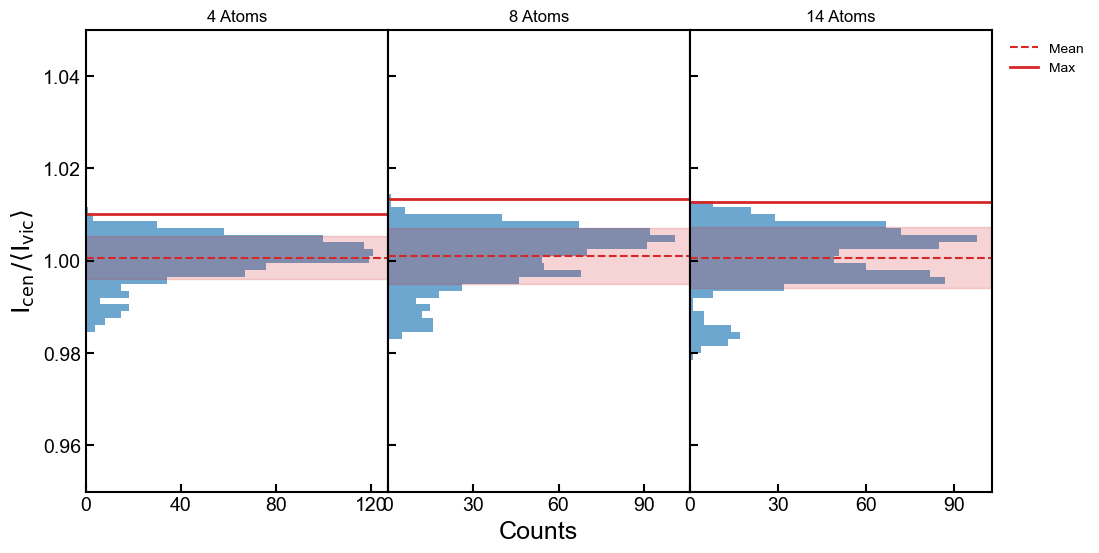

In [3]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": False,
})

y_min, y_max = 0.95, 1.05
bins = np.arange(y_min, y_max + 0.0015, 0.0015)
fig, axes = plt.subplots(1, len(configs), figsize=(12, 6), sharey=True)

for ax, (name, values) in zip(axes, pristine_intensities.items()):
    mean, std, maximum = values.mean(), values.std(), values.max()
    ax.hist(values, bins=bins, color="#1f77b4", alpha=0.65, orientation="horizontal")
    ax.axhspan(mean - std, mean + std, color="#d62728", alpha=0.2)
    ax.axhline(mean, color="#d62728", linestyle="--", label="Mean")
    ax.axhline(maximum, color="#d62728", linewidth=2, label="Max")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[0].set_ylim(y_min, y_max)
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.88)
plt.show()

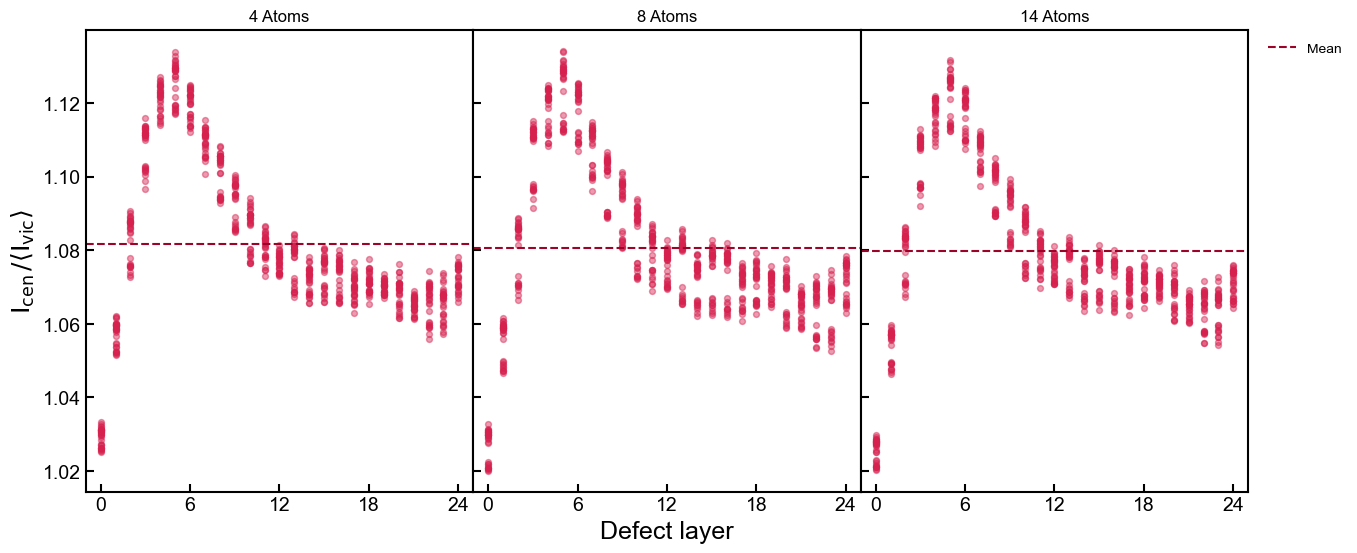

In [4]:
fig, axes = plt.subplots(1, len(configs), figsize=(15, 6), sharey=True)

for ax, (name, values) in zip(axes, lufe_metrics.items()):
    ax.scatter(
        np.repeat(layers, values.shape[1]), values.ravel(),
        color="#D6204E", s=18, alpha=0.45,
    )
    ax.axhline(np.nanmean(values), color="#9D0229", linestyle="--", label="Mean")
    ax.set_title(name)
    ax.set_xlim(-1, len(layers))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5, integer=True))
    ax.tick_params(direction="in", length=6)

axes[1].set_xlabel("Defect layer")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.9)
plt.show()

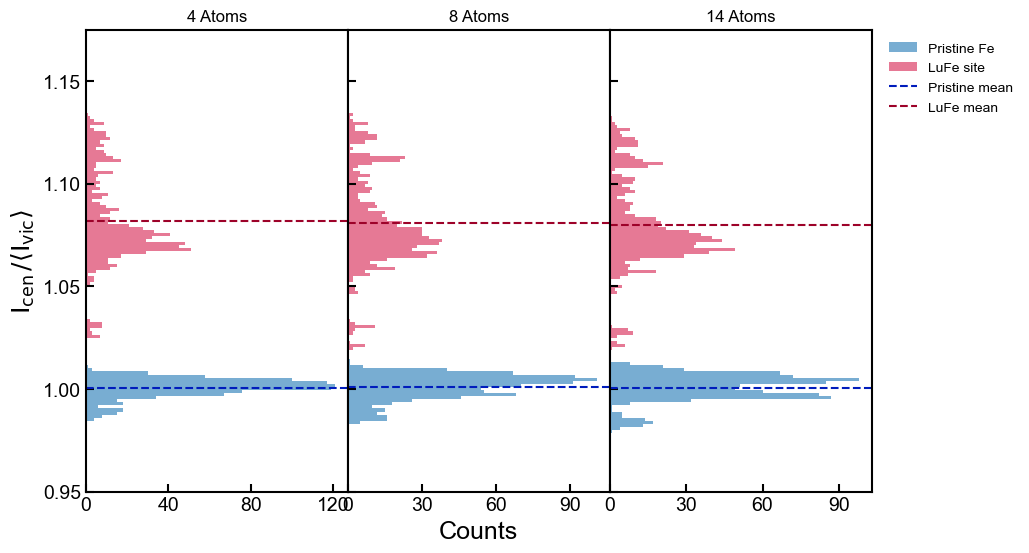

In [6]:
y_min, y_max = 0.95, 1.175
bins = np.arange(y_min, y_max + 0.0015, 0.0015)
fig, axes = plt.subplots(1, len(configs), figsize=(12, 6), sharey=True)

for ax, name in zip(axes, configs):
    pristine = pristine_intensities[name]
    defect = lufe_metrics[name].ravel()
    ax.hist(pristine, bins=bins, color="#1f77b4", alpha=0.6, orientation="horizontal", label="Pristine Fe")
    ax.hist(defect, bins=bins, color="#D6204E", alpha=0.6, orientation="horizontal", label="LuFe site")
    ax.axhline(pristine.mean(), color="#001cbc", linestyle="--", label="Pristine mean")
    ax.axhline(np.nanmean(defect), color="#9D0229", linestyle="--", label="LuFe mean")
    ax.set_title(name)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
    ax.tick_params(direction="in", length=6)

axes[1].set_xlabel("Counts")
axes[0].set_ylabel(r"$\mathrm{I_{cen}} \, / \langle \mathrm{I_{vic}} \rangle$")
axes[0].set_ylim(y_min, y_max)
handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)), frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(wspace=0, right=0.78)
plt.show()